##### _In this notebook, I compare the performance, characteristics and welfare metrics of the 3 main algorithms (DA, SD and MIP) and offer some visualizations for ease of evaluation. All test data is generated from DGP.py and I start with a small, simple default dataset before exploring the sensitivity of certain parameters and end with a simulation using the actual TA postings for the past semester._

In [1]:
import sys, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from DGP import generate_market
from da import deferred_acceptance
from sd import serial_dictatorship
from mip import solve_mip

sns.set_theme(style="whitegrid")
%matplotlib inline

### Simulate test data (default)
First, running all algorithms on simple test dataset simulated as below.

In [2]:
# outline default test 'market' data
SEED = 76
SOLVER = "GUROBI"

m_default = generate_market(n_students=20, n_courses=8, seed=SEED)
print(f"Students : {m_default.n_students}  ({m_default.phd_students.sum()} PhD)")
print(f"Courses  : {m_default.n_courses}  ({m_default.phd_required.sum()} require PhD TA)")
print(f"Total slots: {m_default.capacities.sum()}  (vs {m_default.n_students} students)")

Students : 20  (11 PhD)
Courses  : 8  (3 require PhD TA)
Total slots: 13  (vs 20 students)


In [3]:
# run all algorithms on default simulated data 
def _time(fn, *args, **kwargs):
    t0 = time.perf_counter()
    result = fn(*args, **kwargs)
    return result, time.perf_counter() - t0

a_da, t_da = _time(deferred_acceptance, m_default)
a_sd, t_sd = _time(serial_dictatorship, m_default, seed=SEED)

res_student     = solve_mip(m_default, objective="student",     solver=SOLVER)
res_course      = solve_mip(m_default, objective="course",      solver=SOLVER)
res_bilateral   = solve_mip(m_default, objective="bilateral",   solver=SOLVER)
res_egalitarian = solve_mip(m_default, objective="egalitarian", solver=SOLVER)
res_lp          = solve_mip(m_default, objective="student", lp_relax=True, solver=SOLVER)

results = {
    "DA":              (a_da,                      t_da),
    "SD":              (a_sd,                      t_sd),
    "MIP-student":     (res_student.assignment,    res_student.solve_time),
    "MIP-course":      (res_course.assignment,     res_course.solve_time),
    "MIP-bilateral":   (res_bilateral.assignment,  res_bilateral.solve_time),
    "MIP-egalitarian": (res_egalitarian.assignment,res_egalitarian.solve_time),
    "LP-student":      (res_lp.assignment,         res_lp.solve_time),
}
print("All algorithms done.")


Restricted license - for non-production use only - expires 2027-11-29
All algorithms done.


### Rank

Here I compare the releative choice rank students recieve based on each algorithm using boxpolots (box spans 15th to 75th percentiles).
Low rank means matching is more prefere (top choice is rank = 0), short boxes are more desirable as it shows more equal distribution of choice rank among students.

SD has the longest 'whiskers' suggesting high variance (thus less equality between students). In this test dataset, both DA and MIP yield similar results, with MIP-egaliatrian with the flattest box, showing consistency in rank choice between students. 

Compared to course choice ranking (right plot) students overall have better outcomes, which is true by construction since SD and DA are both student proposing and thus welfare optimal for students. However, note that prioritizing student utility does not significantly detract from course utilities.

(Note, results could be somewhat seed dependent.)

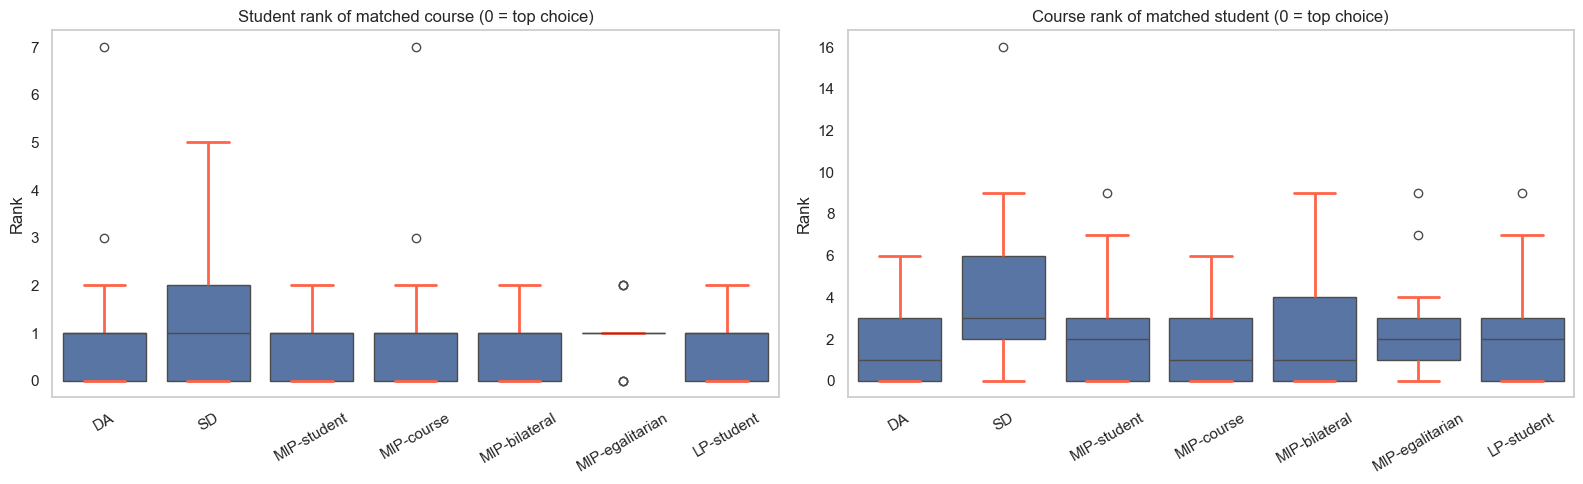

In [21]:
# box plot for each algorithm on student choice rank
# build rank df
rank_rows = []
course_rank_rows = []

for name, (a, _) in results.items():
    for i in range(m_default.n_students):
        if a[i] >= 0:
            j = a[i]
            rank_rows.append({"Algorithm": name, "Rank": int(m_default.student_rankings[i, j])})
            course_rank_rows.append({"Algorithm": name, "Rank": int(m_default.course_rankings[j, i])})

student_rank_df = pd.DataFrame(rank_rows)
course_rank_df = pd.DataFrame(course_rank_rows)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(data=student_rank_df, x="Algorithm", y="Rank", ax=axes[0],
            whiskerprops=dict(color="tomato", linewidth=2),
            capprops=dict(color="tomato", linewidth=2))
axes[0].set_title("Student rank of matched course (0 = top choice)")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)

sns.boxplot(data=course_rank_df, x="Algorithm", y="Rank", ax=axes[1],
            whiskerprops=dict(color="tomato", linewidth=2),
            capprops=dict(color="tomato", linewidth=2))
axes[1].set_title("Course rank of matched student (0 = top choice)")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=30)

for ax in axes.flat:
    ax.grid(False)

plt.tight_layout()
plt.show()


### Objective value

Next, I compare the objective values of total utility and minium student utility across algorithms.

MIP consistency generates matchings which yield highest utility (this is always true since the objective value is to maximize utility) but does not deviate dramatically from DA. SD performs poorly with regard to both total utility and minimum utility.

MIP-egalitarian yields a lower total utility but always a higher minimum utility, demonstrating the tradeoff between fairness and overall utility optimality. 

Note on why min utility may be negative for SD and DA: since utility $u_ij = θ_i · φ_j + ε_{ij}$ is a dot product of normal vectors plus noise — it has no floor, so it can naturally be negative. A negative utility just means student i and course j are a poor match (their latent skill vectors point in opposite directions) but since DA and SD are based off of rankings not utility scores, a student might get their top-ranked course even if the raw utility score for that course happens to be negative, because it's still better than all their other options. This is a limitation of the model; to stay consistent with the standard DA and SD procedures, I did not include the outside option within their preference rankings.

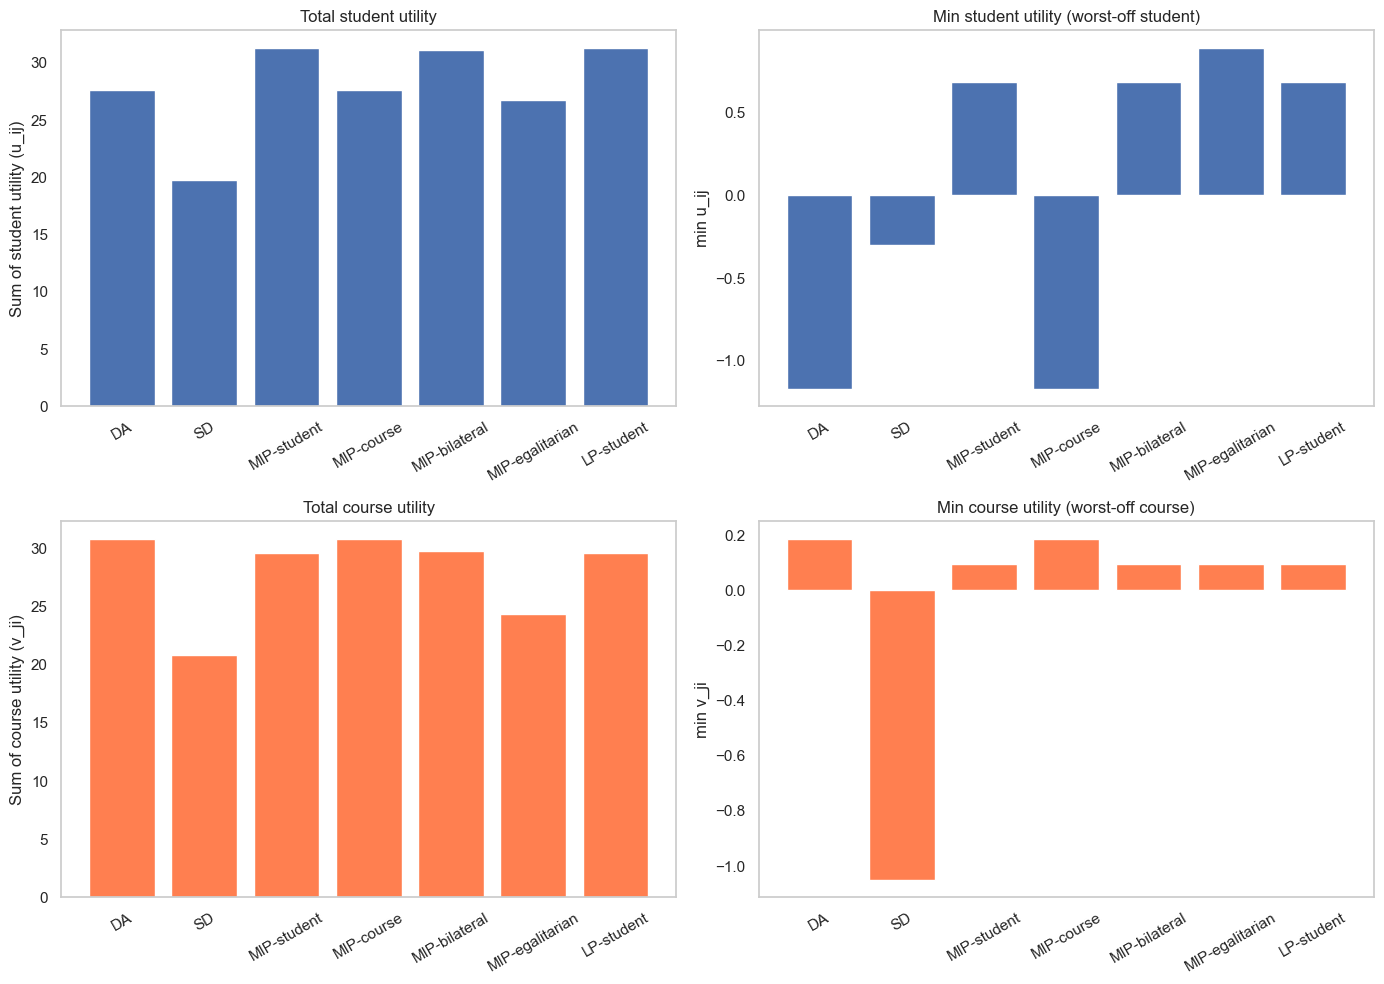

In [5]:
def student_utils(a):
    return [m_default.student_scores[i, a[i]] for i in range(m_default.n_students) if a[i] >= 0]

def course_utils(a):
    return [m_default.course_scores[a[i], i] for i in range(m_default.n_students) if a[i] >= 0]

s_metrics = {name: student_utils(a) for name, (a, _) in results.items()}
c_metrics  = {name: course_utils(a)  for name, (a, _) in results.items()}

total_s = {name: sum(u)  for name, u in s_metrics.items()}
min_s   = {name: min(u)  for name, u in s_metrics.items()}
total_c = {name: sum(u)  for name, u in c_metrics.items()}
min_c   = {name: min(u)  for name, u in c_metrics.items()}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].bar(total_s.keys(), total_s.values())
axes[0,0].set_title("Total student utility")
axes[0,0].set_ylabel("Sum of student utility (u_ij)")
axes[0,0].tick_params(axis="x", rotation=30)

axes[0,1].bar(min_s.keys(), min_s.values())
axes[0,1].set_title("Min student utility (worst-off student)")
axes[0,1].set_ylabel("min u_ij")
axes[0,1].tick_params(axis="x", rotation=30)

axes[1,0].bar(total_c.keys(), total_c.values(), color="coral")
axes[1,0].set_title("Total course utility")
axes[1,0].set_ylabel("Sum of course utility (v_ji)")
axes[1,0].tick_params(axis="x", rotation=30)

axes[1,1].bar(min_c.keys(), min_c.values(), color="coral")
axes[1,1].set_title("Min course utility (worst-off course)")
axes[1,1].set_ylabel("min v_ji")
axes[1,1].tick_params(axis="x", rotation=30)

for ax in axes.flat:
    ax.grid(False)

plt.tight_layout()
plt.show()



### Fairness
Expanding on the previous analysis on the outcome of the 'worst off' student, I examine various measures of fairness which is often a desirable albeit somewhat arbitrary characteristic. I evaluate fairness using 3 main metrics:

*Metrics used*:

Gini coefficient: measures inequality in the distribution of student utilities. For every pair of matched students, compute the absolute difference in their utilities, sum all pairs, and normalise by total utility and number of students. Ranges from 0 (everyone gets identical utility) to 1 (one student gets everything). Since utilities can be negative, shift by subtracting the minimum before computing so Gini index is always positive.

Envy count: for every pair of students (i, i'), counts whether student i prefers i's assigned course over their own — i.e. $u_i,a[i'] > u_i,a[i]$. Unmatched students are counted as envying every matched student. A count of 0 would mean the assignment is envy-free, lower counts indicate less envy overall. I make the assumption that being unmatched is worse than any possible match (to be consistent with SD and DA, so there is no real outside option). 

Rank standard deveation: takes the preference list rank of each matched student's assigned course (0 = top choice) and computes the standard deviation across all matched students. A low std dev means students were treated consistently, i.e. no student got dramatically better or worse treatment relative to others. A high std dev means the algorithm is highly unequal in how well it serves different students.

In [6]:
def gini(utils):
    u = np.sort(np.abs(utils))
    n = len(u)
    return (2 * np.dot(np.arange(1, n+1), u) / (n * u.sum()) - (n+1)/n) if u.sum() > 0 else 0.0

def envy_count(assignment, market):
    count = 0
    for i in range(market.n_students):
        for ip in range(market.n_students):
            if ip == i or assignment[ip] < 0:
                continue # i envies i' if i prefers i''s course over their own current situation
            if assignment[i] < 0: # unmatched i always envies any matched i'
                count += 1
                break
            u_i_own = market.student_scores[i, assignment[i]]
            u_i_gets_ip = market.student_scores[i, assignment[ip]]
            if u_i_gets_ip > u_i_own + 1e-9:
                count += 1
                break
    return count

rows = []
for label, (a, rt) in results.items():
    matched = a[a >= 0]
    utils = np.array([m_default.student_scores[i, a[i]] for i in range(m_default.n_students) if a[i] >= 0])
    all_utils = np.where(a >= 0, m_default.student_scores[np.arange(m_default.n_students), np.clip(a, 0, None)], 0.0)
    rows.append({
        "Algorithm": label,
        "Gini": round(gini(utils), 3) if len(utils) else float("nan"),
        "Envy count": envy_count(a, m_default),
        "Rank std dev": round(float(np.std([m_default.student_rankings[i, a[i]] for i in range(m_default.n_students) 
                                            if a[i] >= 0])), 3),
    })

df_fair = pd.DataFrame(rows).set_index("Algorithm")
display(df_fair)

,Gini,Envy count,Rank std dev
Algorithm,,,
DA,0.420,14,1.887
SD,0.523,16,1.389
MIP-student,0.353,15,0.606
MIP-course,0.420,14,1.887
MIP-bilateral,0.367,15,0.606
MIP-egalitarian,0.301,17,0.679
LP-student,0.353,15,0.606


Overall, it seems like there are tradeoffs between various algorithms and no algorithm dominates on all three metrics. MIP-student is the most consistent (not best at any, but never worst). 

Depending on the metric of fairness, the relative performance of the algorithms also differs; egalitarian is fairest by Gini but least fair by envy, DA and MIP-course have low envy couts but high rank variance.

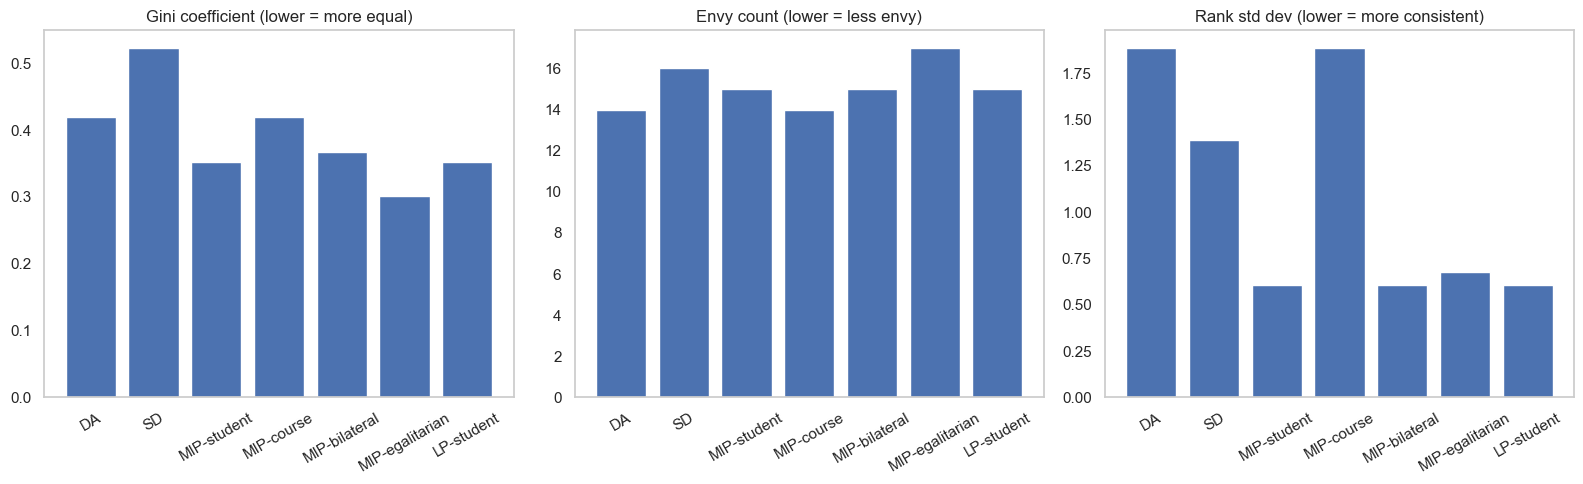

In [7]:
# plot
fairness_df = pd.DataFrame(rows).set_index("Algorithm")
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics_info = [
    ("Gini",         "Gini coefficient (lower = more equal)"),
    ("Envy count",   "Envy count (lower = less envy)"),
    ("Rank std dev", "Rank std dev (lower = more consistent)"),
]

for ax, (col, title) in zip(axes, metrics_info):
    ax.bar(fairness_df.index, fairness_df[col])
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=30)
    ax.grid(False)

plt.tight_layout()
plt.show()

### Stability
A matching is stable if there are no blocking pairs, which is defined as any student-course pair that would prefer to be matched with each other than their current assignment. This is one measure of the efficiency and fairness of the matching algorithm and also what keeps the market from unraveling. 

By construction, the number of blocking pairs for DA is always zero, a key feature of the algorithm. Using DA as the benchmark, the worst performing algorithms are SD and MIP-egalitarian. SD is heavily dependent on the priority order thus creating matchings that are sometimes more stable than others. MIP-egalitarian on the other hand, have an objective that conflicts with the idea of stability; to improve the outcome of the worst student, other students (e.g. a strong student with high utility across many courses and preferred by many courses) may be assigned to a course lower on their preference list to make room for another (weaker) student. Because of these redistributions, blocking pairs are likely to form. In a sense, this also shows the trade-off between stability and equity.

In [23]:
# check for blocking pairs
def count_blocking_pairs(assignment, market):
    pref_set = [set(prefs) for prefs in market.student_prefs]
    blocking = 0
    for i in range(market.n_students):
        for j in range(market.n_courses):
            if j not in pref_set[i]: # course not listed
                continue
            if market.phd_required[j] and not market.phd_students[i]:
                continue
            if i in market.course_rejections[j]:
                continue
            if assignment[i] == j:
                continue
            # does i prefer j over current match (or is unmatched)?
            if assignment[i] >= 0:
                if market.student_rankings[i, j] >= market.student_rankings[i, assignment[i]]:
                    continue
            # can j accommodate i?
            assigned_to_j = np.where(assignment == j)[0]
            if len(assigned_to_j) < market.capacities[j]:
                blocking += 1  # if course j has < capacity
            elif any(market.course_rankings[j, i] < market.course_rankings[j, k]
                     for k in assigned_to_j):
                blocking += 1  # j prefers i over someone it holds
    return blocking

# print table
for label, (a, _) in results.items():
    bp = count_blocking_pairs(a, m_default)
    print(f"{label:20s}  blocking pairs: {bp}")


DA                    blocking pairs: 0
SD                    blocking pairs: 13
MIP-student           blocking pairs: 5
MIP-course            blocking pairs: 0
MIP-bilateral         blocking pairs: 3
MIP-egalitarian       blocking pairs: 10
LP-student            blocking pairs: 5


### Other welfare measures / pareto-efficiency (?)

Pareto-efficieny is difficult to calculate directly, but have some other ways to test or compare since MIP optimized solution is by construction utility maximizing on aggregate. Here, I compare how decentralized matching algorithms SD and DA does compared to the centralized system (MIP) to see how much improvement involving a 'social planner' might actually bring.

Specifically, 3 measure of welfare I consider here are:

* Aggregate welfare: total student utility under MIP minus total utility under DA or SD
* Dominated students: how many students are strictly worse off under DA or SD. Graphically, this is shown as a heatmap where each row = one algorithm, each column = one student. Color represents how the utility of that student changes between MIP and other algorithms
* Utility gap: for each student, gives the utlity difference between MIP and DA or SD

<b>Commentary </b>

_Aggregate uility_
DA foregoes ~3.5 units vs MIP-student, SD foregoes ~11.5. With ~15 students matched at utilities around 1-2 each, total welfare is roughly 20-30, so DA loses ~10-15% of potential welfare suggesting that a social planner captures gains a decentralised mechanism leaves on the table. 

_Heatmap_
Students 0-3 are dark green under DA meaning they are better off under DA than under the social planner. The social planner is actively making those students worse off to increase the total. MIP-student redistributes welfare away from students who would do well under student-proposing DA (the high-ability students who get top choices early) toward others. These are the strong students that do well in DA (student proposing) due to high utilities across courses.

_Pareto improvement comparison_
DA has 2 students strictly worse off vs MIP-student. So the social planner does not Pareto dominate DA and those students would rationally prefer DA over the social planner. SD also has 3 students that would prefer it to a centralized system, suggesting that while a social planner increases overall efficiency, the way its distributionally affects each student is different thus, it's more difficult to conclude whether a centralized system would be a more optimal solution.

,Welfare loss,Worse off,Same,Better off
Algorithm,,,,
DA,3.606,2,7,2
SD,11.469,4,3,3
MIP-course,3.606,2,7,2
MIP-bilateral,0.112,1,11,1
MIP-egalitarian,4.544,2,9,0
LP-student,0.000,0,13,0


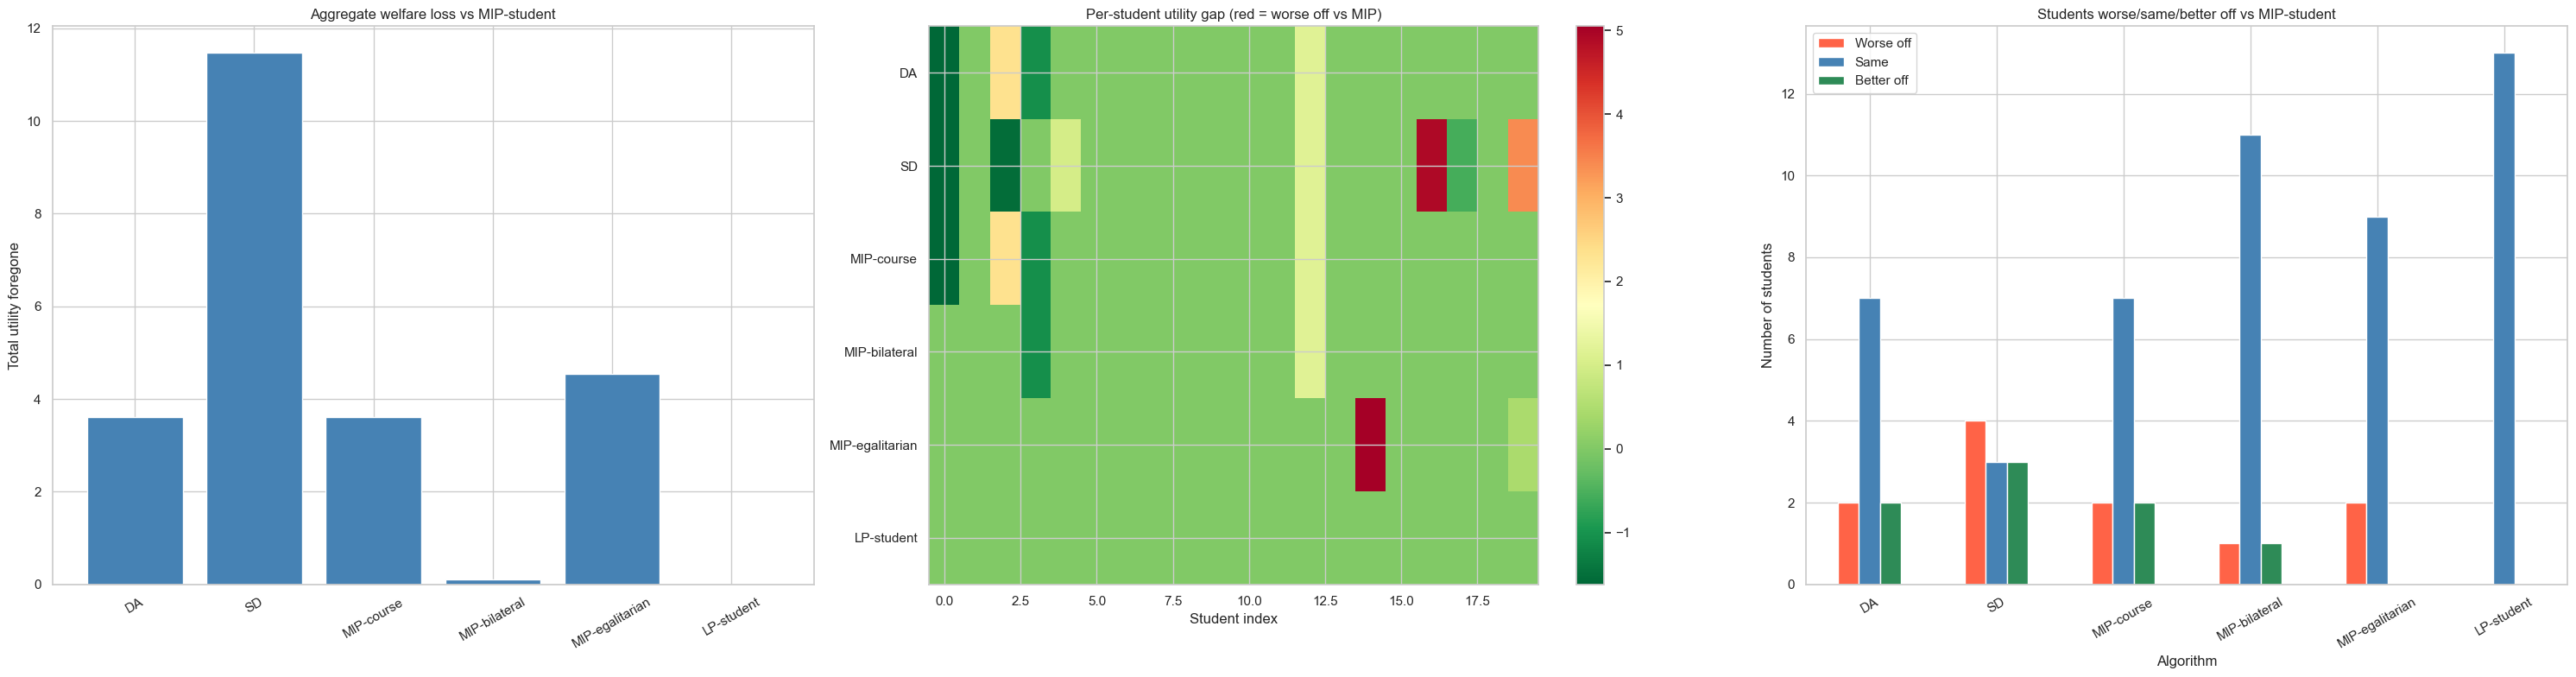

In [24]:
mip_a = results["MIP-student"][0]
comparisons = [k for k in results if k != "MIP-student"]

def student_utility(assignment, market):
    return np.array([
        market.student_scores[i, assignment[i]] if assignment[i] >= 0 else np.nan
        for i in range(market.n_students)
    ])

mip_utils = student_utility(mip_a, m_default)
mip_total = np.nansum(mip_utils)

# aggregate welfare loss
rows = []
# by algorithm
for label in comparisons:
    a = results[label][0]
    alg_utils = student_utility(a, m_default)
    gap = mip_utils - alg_utils
    rows.append({
        "Algorithm": label,
        "Welfare loss": round(mip_total - np.nansum(alg_utils), 3),
        "Worse off": int(np.sum(gap >  1e-9)),
        "Same":      int(np.sum(np.abs(gap) <= 1e-9)),
        "Better off":int(np.sum(gap < -1e-9)),
    })

df_welfare = pd.DataFrame(rows).set_index("Algorithm")
display(df_welfare)

# plot
fig, axes = plt.subplots(1, 3, figsize=(30, 8))

axes[0].bar(df_welfare.index, df_welfare["Welfare loss"], color="steelblue")
axes[0].set_title("Aggregate welfare loss vs MIP-student")
axes[0].set_ylabel("Total utility foregone")
axes[0].tick_params(axis="x", rotation=30)

gap_matrix = np.array([
    np.nan_to_num(mip_utils - student_utility(results[l][0], m_default), nan=0.0)
    for l in comparisons
])
im = axes[1].imshow(gap_matrix, aspect="auto", cmap="RdYlGn_r")
axes[1].set_yticks(range(len(comparisons)))
axes[1].set_yticklabels(comparisons)
axes[1].set_xlabel("Student index")
axes[1].set_title("Per-student utility gap (red = worse off vs MIP)")
plt.colorbar(im, ax=axes[1])

df_welfare[["Worse off", "Same", "Better off"]].plot(
    kind="bar", ax=axes[2], color=["tomato", "steelblue", "seagreen"], legend=True
)
axes[2].set_title("Students worse/same/better off vs MIP-student")
axes[2].set_ylabel("Number of students")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


### Computational efficiency

I also look at computational efficiency with run time and match rates.

Regarding runtime DA and SD are simple iterative algorithms, they are the fastet to implement. Amoung the MIP objectives, egalitarian should take longest since it runs two solver calls (phase 1 for max matches and phase 2 for min-utility).

Note that in the case in the default market dataset where there are more students than available slots, not all students can be matched. DA and SD attempt to fill all slots subject to PhD constraints, while MIP-student may leave students unmatched if their utility for all available courses is negative, since the outside option of remaining unmatched (utility 0) is preferred by the optimiser.

,Runtime (s),Match rate
Algorithm,,
DA,0.000121,0.65
SD,0.000094,0.65
MIP-student,0.029274,0.65
MIP-course,0.003150,0.65
MIP-bilateral,0.004024,0.65
MIP-egalitarian,0.047285,0.65
LP-student,0.002473,0.65


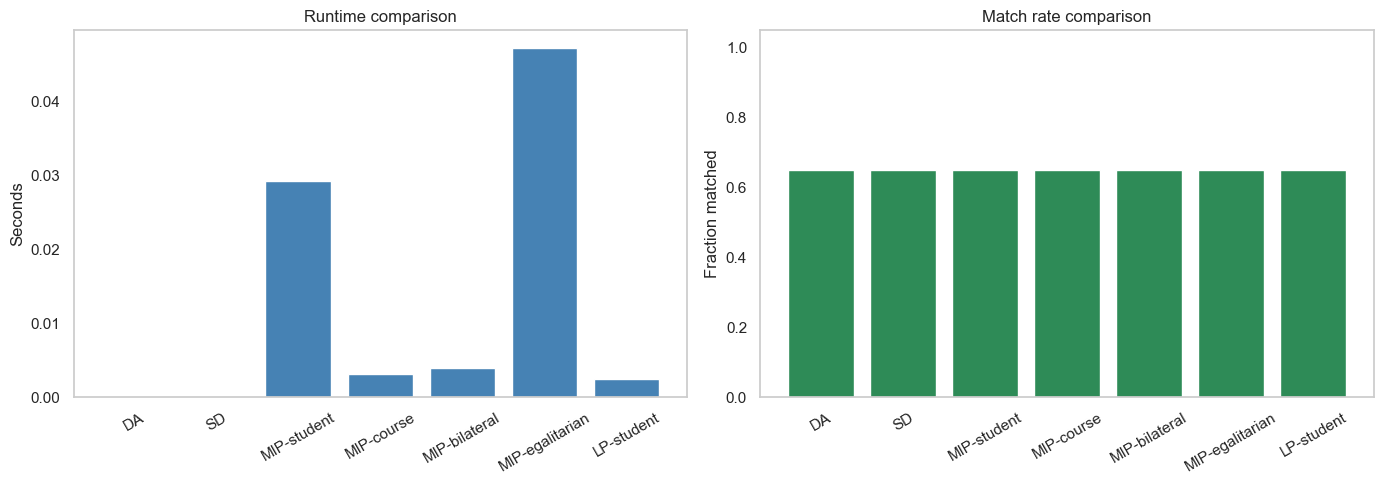

In [10]:
# plot runtime and match rate
summary_rows = []
for label, (a, rt) in results.items():
    summary_rows.append({
        "Algorithm": label,
        "Runtime (s)": rt,
        "Match rate": (a >= 0).sum() / m_default.n_students,
    })

df_summary = pd.DataFrame(summary_rows).set_index("Algorithm")
display(df_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(df_summary.index, df_summary["Runtime (s)"], color="steelblue")
axes[0].set_title("Runtime comparison")
axes[0].set_ylabel("Seconds")
axes[0].tick_params(axis="x", rotation=30)
axes[0].grid(False)

axes[1].bar(df_summary.index, df_summary["Match rate"], color="seagreen")
axes[1].set_title("Match rate comparison")
axes[1].set_ylabel("Fraction matched")
axes[1].set_ylim(0, 1.05)
axes[1].tick_params(axis="x", rotation=30)
axes[1].grid(False)

plt.tight_layout()
plt.show()


Results could be seed dependent, I also test across a series of random seeds, which yield similar results.

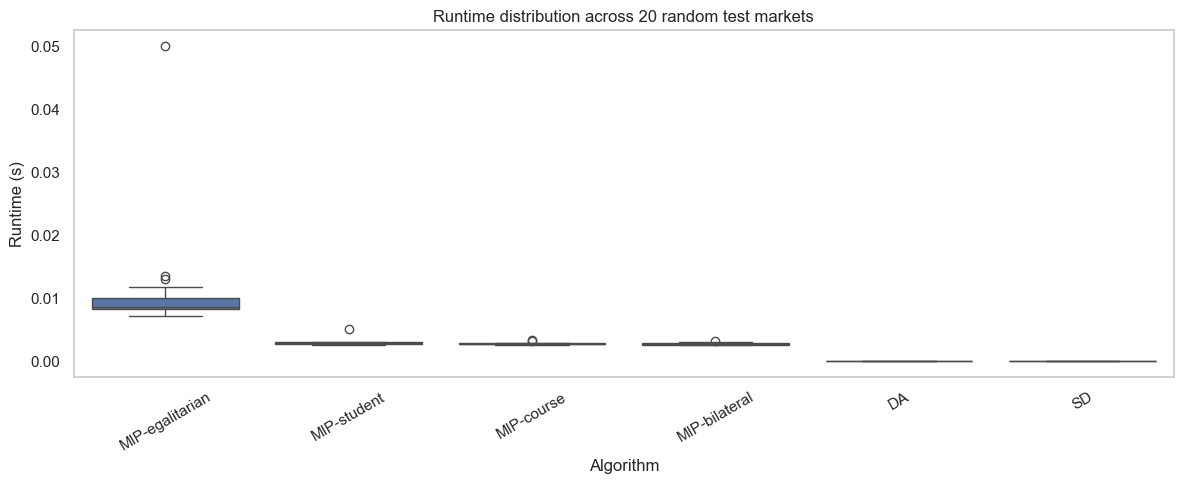

,mean,std,min,max
Algorithm,,,,
DA,0.0001,0.0000,0.0001,0.0001
MIP-bilateral,0.0028,0.0002,0.0025,0.0032
MIP-course,0.0028,0.0002,0.0026,0.0034
MIP-egalitarian,0.0113,0.0093,0.0072,0.0500
MIP-student,0.0030,0.0005,0.0026,0.0051
SD,0.0001,0.0000,0.0000,0.0001


In [11]:
# check runtime for different algorithms over multiple seeds
import warnings
SEEDS = range(20)
runtime_records = []

for seed in SEEDS:
    mkt = generate_market(n_students=20, n_courses=8, seed=seed)
    for obj in ("student", "course", "bilateral", "egalitarian"):
        t0 = time.perf_counter()
        solve_mip(mkt, objective=obj, solver=SOLVER)
        runtime_records.append({"Algorithm": f"MIP-{obj}", "Runtime (s)": time.perf_counter() - t0, "Seed": seed})
    for label, fn in [("DA", deferred_acceptance), ("SD", lambda mkt: serial_dictatorship(mkt, seed=seed))]:
        t0 = time.perf_counter()
        fn(mkt)
        runtime_records.append({"Algorithm": label, "Runtime (s)": time.perf_counter() - t0, "Seed": seed})

df_rt = pd.DataFrame(runtime_records)

fig, ax = plt.subplots(figsize=(12, 5))
order = df_rt.groupby("Algorithm")["Runtime (s)"].mean().sort_values(ascending=False).index
sns.boxplot(data=df_rt, x="Algorithm", y="Runtime (s)", order=order, ax=ax)
ax.set_title("Runtime distribution across 20 random test markets")
ax.tick_params(axis="x", rotation=30)
ax.grid(False)
plt.tight_layout()
plt.show()

display(df_rt.groupby("Algorithm")["Runtime (s)"].agg(["mean", "std", "min", "max"]).round(4))


### Robustness check across seeds
Given the simulated market data could be very sensitive to the seed, I repeat some of the above comparisons averaging over 10 random seeds and visualized with box-charts.

<b>Commentary </b>
Total welfare (top left): MIP-student highest, SD lowest, DA in between — consistent with single-seed. But notice DA's IQR is wide, meaning its welfare is quite seed-dependent. MIP-student is tighter, suggesting centralisation is more robust, not just better on average.

Min student welfare (top middle): MIP-student has the highest floor, egalitarian second, DA and SD negative. MIP-student consistently protects the worst-off matched student better than egalitarian because it excludes negative-utility students from being matched at all. (In other words, egalitarian is maximising the minimum of a larger, worse set of students since phase 1 forces max possible matches first, while MIP-student is maximising total welfare over a smaller, better-screened set and its minimum just happens to be higher.)

Mean rank (top right): MIP-student is best and tightest — very consistent across seeds. This isn't a surprising result but shows the solver is performing as intended.

Match rate (bottom left): Egalitarian has the highest match rate (which is guaranteed by the first phase) consistently. MIP-student has lower and more variable match rate — the outside option effect is robust and seed-dependent in magnitude.

Blocking pairs (bottom middle): DA is exactly 0 every seed by construction. MIP-egalitarian (~16 median) is nearly as bad as SD (~20).

Gini index (bottom right): This is where the multi-seed result slightly contradicts the single seed — MIP-student has the lowest Gini here, not egalitarian. The single-seed result showing egalitarian winning on Gini was somewhat idiosyncratic. Across seeds, all four algorithms are actually quite similar on Gini with overlapping IQRs — Gini may just not be a strong discriminator between these algorithms.

Overall: The core findings hold robustly — DA is stable and efficient, SD is simple but does not perform well, MIP-student dominates on welfare and rank consistency, egalitarian helps match rate but hurts stability. A key observation is that after running multiple seeds, DA's results are more variable than MIP's, strengthening the case that centralisation is more reliable to changes in underlying perferences, not just higher-performing in expectation.

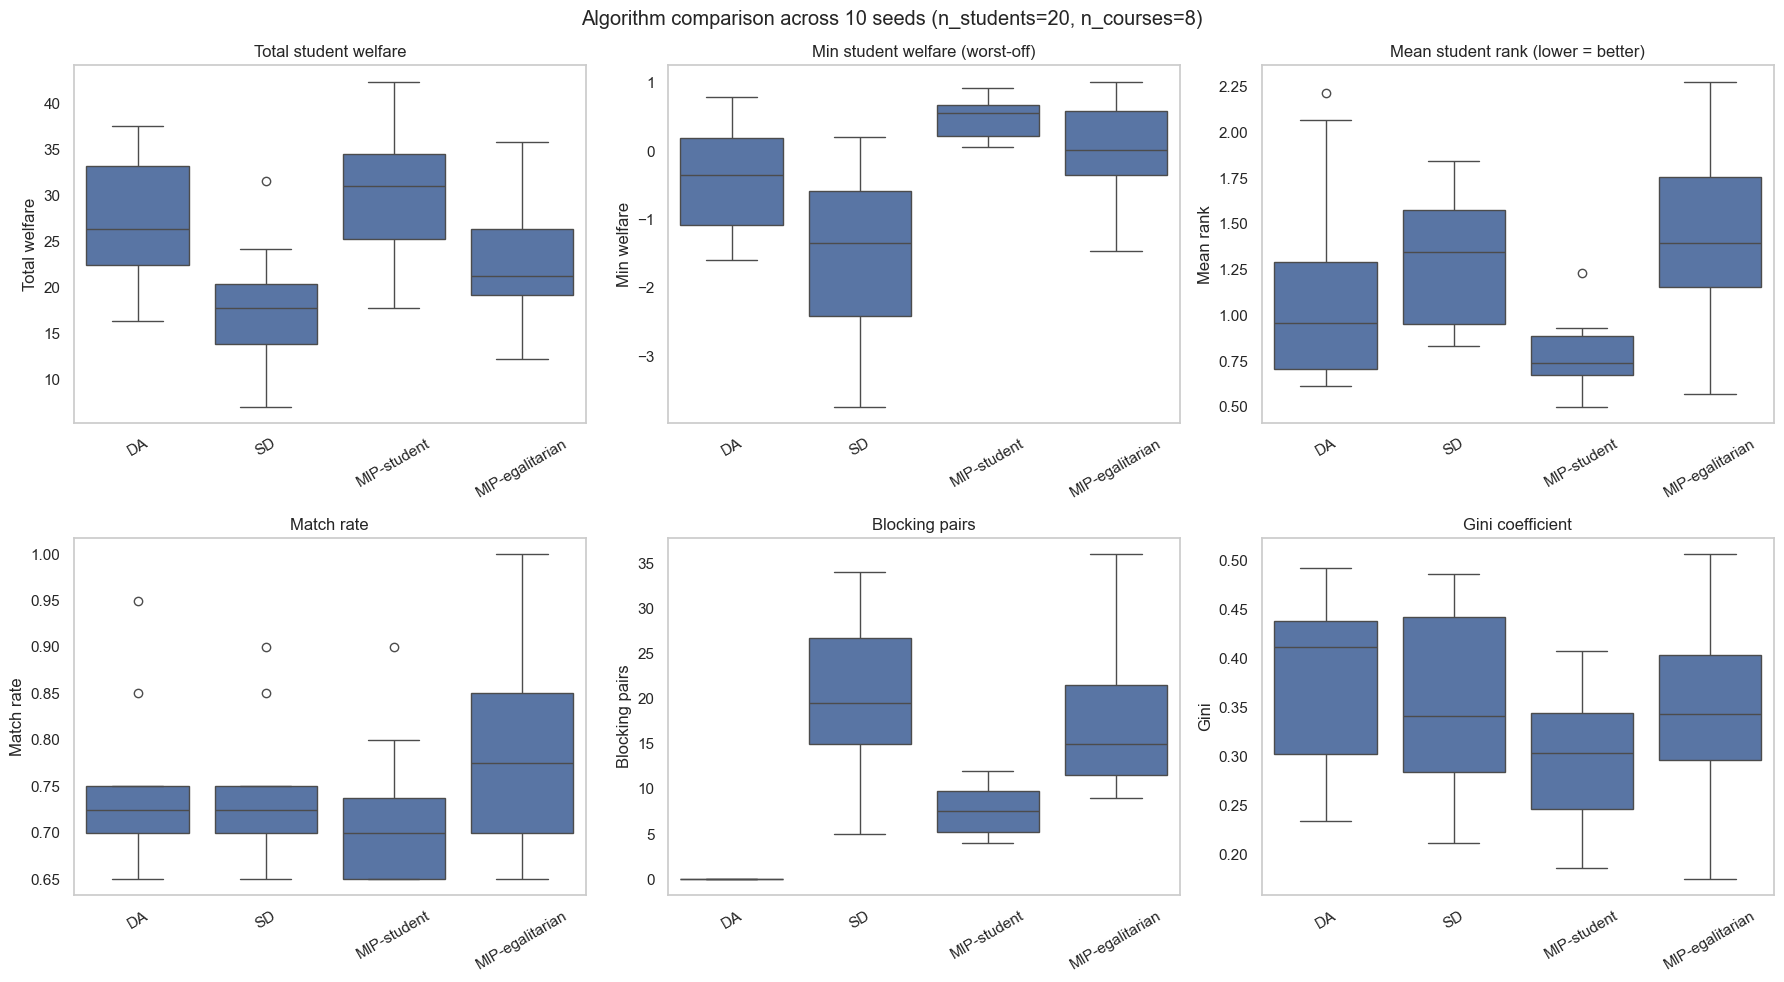

In [12]:
ALGOS_ROBUST = ["DA", "SD", "MIP-student", "MIP-egalitarian"]

robust_records = []
for seed in range(10):
    mkt = generate_market(n_students=20, n_courses=8, seed=seed)
    assignments = {
        "DA":              deferred_acceptance(mkt),
        "SD":              serial_dictatorship(mkt, seed=seed),
        "MIP-student":     solve_mip(mkt, objective="student",     solver=SOLVER).assignment,
        "MIP-egalitarian": solve_mip(mkt, objective="egalitarian", solver=SOLVER).assignment,
    }
    for algo, a in assignments.items():
        utils = [mkt.student_scores[i, a[i]] for i in range(mkt.n_students) if a[i] >= 0]
        ranks = [mkt.student_rankings[i, a[i]] for i in range(mkt.n_students) if a[i] >= 0]
        robust_records.append({
            "Algorithm":      algo,
            "Seed":           seed,
            "Total welfare":  sum(utils) if utils else 0.0,
            "Min welfare":    min(utils) if utils else float("nan"),
            "Mean rank":      float(np.mean(ranks)) if ranks else float("nan"),
            "Match rate":     float((a >= 0).sum()) / mkt.n_students,
            "Blocking pairs": count_blocking_pairs(a, mkt),
            "Gini":           gini(utils) if utils else float("nan"),
        })

df_robust = pd.DataFrame(robust_records)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Algorithm comparison across 10 seeds (n_students=20, n_courses=8)")

for ax, (col, title) in zip(axes.flat, [
    ("Total welfare",  "Total student welfare"),
    ("Min welfare",    "Min student welfare (worst-off)"),
    ("Mean rank",      "Mean student rank (lower = better)"),
    ("Match rate",     "Match rate"),
    ("Blocking pairs", "Blocking pairs"),
    ("Gini",           "Gini coefficient"),
]):
    sns.boxplot(data=df_robust, x="Algorithm", y=col, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)
    ax.grid(False)

plt.tight_layout()
plt.show()


### Sensitivity of underlying data (experiments with new simulated datasets)
The following look at how sensitive welfare outcomes are as parameters change. In particular I test changes across noise level (σ), skill vector dimension (k), preference list length (sparse markets), and course popularity concentration.

Note that algorithms included are only DA, SD MIP-student and MIP-egalitarian for simplicity. 

In [13]:
ALGOS = ["DA", "SD", "MIP-student", "MIP-egalitarian"]

def run_experiment(param_name, param_values, n_seeds=10, **fixed_kwargs):
    records = []
    for val in param_values:
        kwargs = {**fixed_kwargs, param_name: val}
        for seed in range(n_seeds):
            mkt = generate_market(n_students=20, n_courses=8, seed=seed, **kwargs)
            assignments = {
                "DA":  deferred_acceptance(mkt),
                "SD":  serial_dictatorship(mkt, seed=seed),
            }
            for obj in ("student", "egalitarian"):
                assignments[f"MIP-{obj}"] = solve_mip(mkt, objective=obj, solver=SOLVER).assignment

            for algo, a in assignments.items():
                records.append({
                    "param":          val,
                    "Algorithm":      algo,
                    "Welfare":        sum(mkt.student_scores[i, a[i]] for i in range(mkt.n_students) if a[i] >= 0),
                    "Blocking pairs": count_blocking_pairs(a, mkt),
                    "Match rate":     (a >= 0).sum() / mkt.n_students,
                })
    return pd.DataFrame(records)

def plot_experiment(df, param_label, title):
    metrics = [("Welfare", "Total student welfare"),
               ("Blocking pairs", "Blocking pairs"),
               ("Match rate", "Match rate")]
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(title)
    for ax, (metric, ylabel) in zip(axes, metrics):
        for algo in ALGOS:
            sub = df[df["Algorithm"] == algo].groupby("param")[metric].mean()
            ax.plot(sub.index, sub.values, marker="o", label=algo)
        ax.set_xlabel(param_label)
        ax.set_ylabel(ylabel)
        ax.set_title(ylabel)
        ax.legend(fontsize=8)
        ax.grid(False)
    plt.tight_layout()
    plt.show()


#### Changing the noice term
Noise level (σ) controls how much idiosyncratic preference variation there is relative to the common skill-match signal (θᵢ·φⱼ). At low σ, most students prefer the same courses; at high σ, preferences are heterogeneous and driven by luck of the draw.

Total welfare rises for all algorithms as σ increases — higher variance produces larger realised utility draws, and any algorithm that follows preferences will capture some of those gains. MIP-student benefits most because it can globally optimise over the entire utility matrix, exploiting extreme positive realisations that DA and SD might miss. The gap between MIP-student and the decentralised mechanisms widens, suggesting the value of a social planner is larger in noisier, more heterogeneous markets.

Blocking pairs for DA remain exactly zero by construction. MIP-student's blocking pairs rise with σ as preferences become more idiosyncratic, the welfare-maximising assignment diverges further from the stable one. SD and egalitarian are roughly flat because their blocking pairs are already high at low σ and driven by other factors.

DA and SD match rates increase with σ: heterogeneous preferences spread student demand more evenly across courses, reducing congestion and allowing more students to find a slot. MIP-egalitarian stays flat since phase 1 always fills as many slots as possible regardless of σ. MIP-student's match rate falls at high σ because more students accumulate all-negative utility draws; the optimiser exercises its implicit outside option and leaves them unmatched rather than drag down total welfare. This highlights a key limitation of the utilitarian objective in noisy markets.

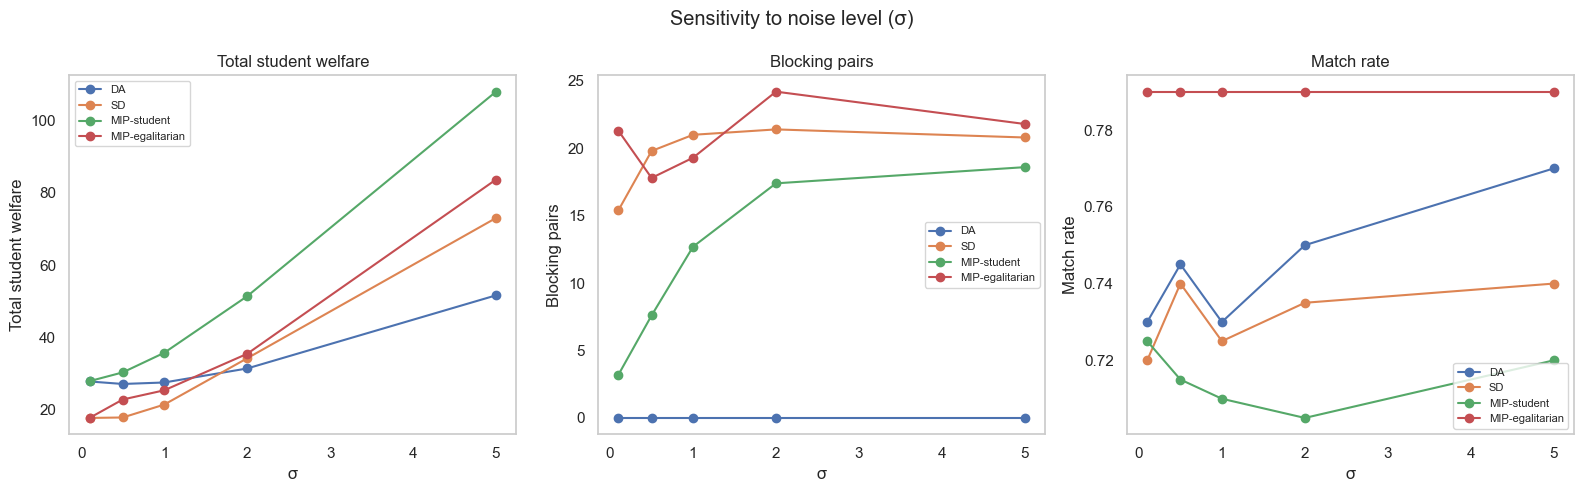

In [14]:
df_sigma = run_experiment("sigma", [0.1, 0.5, 1.0, 2.0, 5.0])
plot_experiment(df_sigma, "σ", "Sensitivity to noise level (σ)")

### Changing dimensionality of the latent skill / trait vector

Skill dimension (k) controls the richness of the latent skill space. At k=1, student-course compatibility is determined by a single trait; at k=10, it reflects alignment across ten independent dimensions, producing more dispersed and differentiated preferences.

Total welfare rises with k for all algorithms; higher-dimensional skill vectors produce more varied dot products, so the best matches become substantially better. MIP-student and DA converge at high k, suggesting DA captures most of the available gains when preferences are rich and well-differentiated. SD consistently falls behind.

Blocking pairs fall with k for MIP-student. More complicated preferences make the welfare-maximising assignment more aligned with the stable one, since genuinely good matches are good for both sides.

Match rate for MIP-student declines with k as higher-dimensional skill vectors increase the chance some students are a poor fit everywhere, triggering the outside option more frequently. Egalitarian's match rate stays higher throughout, again due to the first phase objective.

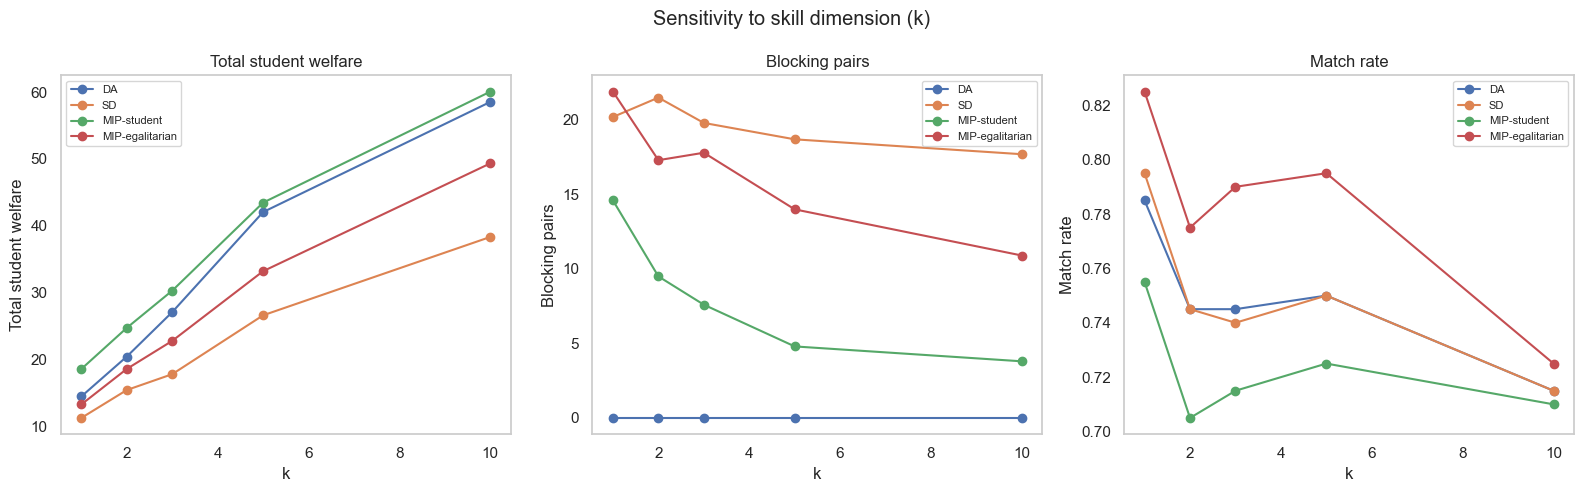

In [15]:
df_k = run_experiment("k", [1, 2, 3, 5, 10])
plot_experiment(df_k, "k", "Sensitivity to skill dimension (k)")


### Sparse preferences
Preference list length controls how many courses each student submits in their ranked list, from 1 (top choice only) to 8 (full ranking). Shorter lists reflect realistic settings where students only express interest in courses they genuinely want to TA, but create a harder matching problem since students cannot be rerouted to unlisted alternatives if their preferred courses are full.

Total welfare is flat for both MIP algorithms regardless of list length as it optimizes directly over the utility matrix and never consult submitted preference lists. SD is more volatile and does not recover as cleanly.

Blocking pairs rise mechanically with list length for all non-DA algorithms, since the blocking pair check only considers listed courses. A remains exactly zero throughout, as stability holds with respect to whatever list is submitted.

Regarding match-rates, MIP algorithms are unaffected. DA and SD recover quickly as list length grows and converge near full-list match rates. Decentralised mechanisms are highly sensitive to incomplete preference submission, suggesting the department should require students to submit full rankings rather than top choices only.

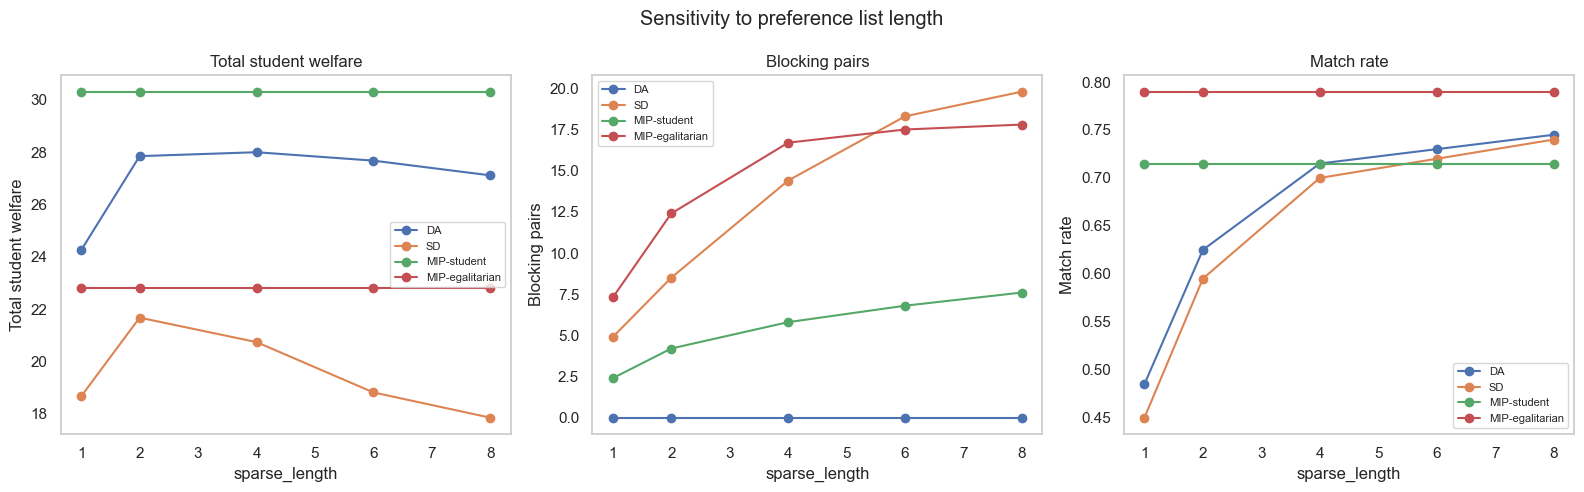

In [16]:
df_sparse = run_experiment("sparse_length", [1, 2, 4, 6, 8], sparse_prefs=True)
plot_experiment(df_sparse, "sparse_length", "Sensitivity to preference list length")

### What if some courses are more popular than others?

Course popularity concentration adds a shared popularity weight term to all students' utility for each course. At weight=0 preferences are purely based on latent skill alignment; at weight=10, one or two courses become universally desirable regardless of individual skill alignment, creating intense competition for a small number of slots.

MIP-student's welfare increases significantly, it identifies the universally high-utility courses and routes the best-fitting students there. DA benefits more modestly since student-proposing dynamics naturally direct students toward popular courses, but rejected students must settle for less. SD and egalitarian barely move; egalitarian is constrained to distribute students broadly rather than concentrate them on the popular courses.

Blocking pairs rise for all non-DA algorithms as popularity increases; a universally desired course creates many students who prefer it over their current match and would be preferred by the course over some current occupant. DA remains zero throughout as it is stability by construction prevents this even when one course is overwhelmingly popular.

MIP-student's match rate collapses to near zero when unpopular courses become so undesirable that all remaining students trigger the outside option and are left unmatched. DA, SD and egalitarian are unaffected, since they have no outside option and route rejected students down their preference lists regardless.

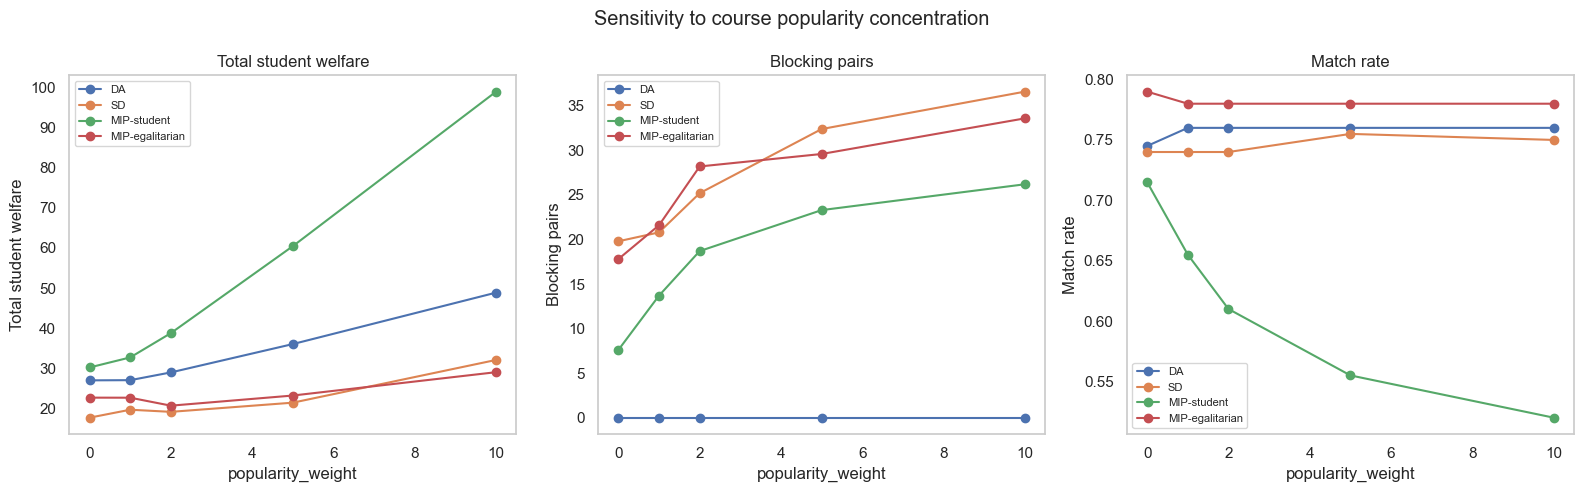

In [17]:
df_pop = run_experiment("popularity_weight", [0, 1, 2, 5, 10])
plot_experiment(df_pop, "popularity_weight", "Sensitivity to course popularity concentration")

### Using Winter 2026 TA assignment as an example
See attached TA POSTING doc for available positions. I assume the same number of students as positions so everyone is matched.

In [18]:
# Real VSE TA market from Winter 2025-26
REAL_COURSES = [
    "ECON101", "ECON102", "ECON221", "ECON241", "ECON301", "ECON302",
    "ECON306", "ECON307/408", "ECON309", "ECON316", "ECON317", "ECON323",
    "ECON325", "ECON326", "ECON328", "ECON345", "ECON351", "ECON355",
    "ECON356", "ECON398", "ECON425", "ECON442", "ECON456", "ECON473",
    "ECON490", "ECON490/553", "ECON492C", "ECON494", "ECON601", "ECON603",
    "ECON627",
]
REAL_CAPS = np.array([
    6, 20, 2, 1, 1, 2, 1, 1, 1, 1, 2, 1,
    1, 1, 1, 3, 1, 3, 3, 1, 1, 2, 2, 1,
    1, 1, 1, 1, 1, 1, 1,
])
REAL_PHD = np.array([
    False, False, False, False, False, False,
    False, False, False, False, False, False,
    False, False, False, False, False, False,
    False, False, False, False, False, False,
    False, False, False, False, True, True, True,  # 601, 603, 627 (graduate level courses)
])

assert len(REAL_COURSES) == len(REAL_CAPS) == len(REAL_PHD)
n_slots = int(REAL_CAPS.sum())
print(f"Courses: {len(REAL_COURSES)}, Total slots: {n_slots}, Students: {n_slots}")

m_real = generate_market(
    n_students=n_slots,
    n_courses=len(REAL_COURSES),
    fixed_capacities=REAL_CAPS,
    fixed_course_codes=REAL_COURSES,
    fixed_phd_required=REAL_PHD,
    rejection_fraction=0.0,  # no rejection lists for real market (assumed...can't get this info)
    seed=SEED,
)


Courses: 31, Total slots: 66, Students: 66


Run all algorithms (using HiGHS for MIP since GUROBI license has limits on size)

In [19]:
# run all algorithms on real market
results_real = {
    "DA":  (deferred_acceptance(m_real), None),
    "SD":  (serial_dictatorship(m_real, seed=SEED), None),
    "MIP-student":     (solve_mip(m_real, objective="student",     solver="HIGHS").assignment, None),
    "MIP-egalitarian": (solve_mip(m_real, objective="egalitarian", solver="HIGHS").assignment, None),
}


# summary table
rows = []
for label, (a, _) in results_real.items():
    matched = (a >= 0).sum()
    ranks = [m_real.student_rankings[i, a[i]] for i in range(m_real.n_students) if a[i] >= 0]
    utils = [m_real.student_scores[i, a[i]] for i in range(m_real.n_students) if a[i] >= 0]
    rows.append({
        "Algorithm":    label,
        "Matched":      matched,
        "Mean rank":    round(np.mean(ranks), 2),
        "Median rank":  int(np.median(ranks)),
        "Total welfare": round(sum(utils), 2),
        "Min welfare":  round(min(utils), 2),
        "Blocking pairs": count_blocking_pairs(a, m_real),
    })

display(pd.DataFrame(rows).set_index("Algorithm"))



,Matched,Mean rank,Median rank,Total welfare,Min welfare,Blocking pairs
Algorithm,,,,,,
DA,66,5.35,3,133.54,-4.08,0
SD,66,4.23,2,123.79,-1.93,116
MIP-student,64,2.86,2,162.68,0.10,50
MIP-egalitarian,66,3.44,3,127.19,1.02,171


In [27]:
# outcomes!
pd.set_option("display.max_colwidth", None)

assign_rows = []
for j in range(m_real.n_courses):
    row = {
        "Course":  m_real.course_codes[j],
        "Cap":     m_real.capacities[j],
        "PhD":     "✓" if m_real.phd_required[j] else "",
    }
    for label, (a, _) in results_real.items():
        assigned = [m_real.student_names[i] for i in range(m_real.n_students) if a[i] == j]
        fill = f"{len(assigned)}/{m_real.capacities[j]}"
        row[label] = f"[{fill}] " + (", ".join(assigned) if assigned else "—")
    assign_rows.append(row)

df_assign = pd.DataFrame(assign_rows).set_index("Course")
display(df_assign.style.set_properties(**{"text-align": "left"})
                       .set_table_styles([{"selector": "th", "props": [("text-align", "left")]}]))


,Cap,PhD,DA,SD,MIP-student,MIP-egalitarian
Course,,,,,,
ECON101,6,,"[6/6] Xi, Rho2, Chi2, Omega2, Iota3, Rho3","[6/6] Zeta, Mu, Upsilon2, Chi2, Iota3, Kappa3","[6/6] Mu, Xi, Rho2, Upsilon2, Chi2, Omega2","[6/6] Eta, Omicron, Tau, Chi, Iota3, Xi3"
ECON102,20,,"[20/20] Gamma, Theta, Nu, Sigma, Phi, Gamma2, Delta2, Epsilon2, Kappa2, Lambda2, Mu2, Nu2, Pi2, Upsilon2, Phi2, Psi2, Delta3, Epsilon3, Eta3, Sigma3","[20/20] Alpha, Gamma, Nu, Tau, Phi, Beta2, Gamma2, Delta2, Epsilon2, Zeta2, Kappa2, Xi2, Phi2, Psi2, Beta3, Delta3, Eta3, Theta3, Mu3, Sigma3","[19/20] Alpha, Delta, Nu, Phi, Delta2, Epsilon2, Zeta2, Kappa2, Lambda2, Xi2, Pi2, Phi2, Psi2, Beta3, Delta3, Epsilon3, Eta3, Nu3, Sigma3","[20/20] Alpha, Gamma, Delta, Epsilon, Lambda, Nu, Phi, Epsilon2, Zeta2, Kappa2, Lambda2, Xi2, Phi2, Chi2, Psi2, Beta3, Delta3, Epsilon3, Eta3, Nu3"
ECON221,2,,"[2/2] Tau, Pi3","[2/2] Nu2, Pi3","[2/2] Rho, Nu2","[2/2] Upsilon2, Pi3"
ECON241,1,,[1/1] Alpha2,[1/1] Iota,[1/1] Pi3,[1/1] Gamma3
ECON301,1,,[1/1] Alpha3,[1/1] Eta2,[1/1] Tau2,[1/1] Iota2
ECON302,2,,"[2/2] Upsilon, Omicron3","[2/2] Pi, Psi","[2/2] Upsilon, Iota2","[2/2] Pi, Alpha3"
ECON306,1,,[1/1] Omega,[1/1] Omega,[1/1] Omega,[1/1] Omega
ECON307/408,1,,[1/1] Theta3,[1/1] Alpha2,[1/1] Alpha2,[1/1] Gamma2
ECON309,1,,[1/1] Omicron,[1/1] Omicron,[1/1] Omicron,[1/1] Delta2
